In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [15]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
EPOCHS = 10

train_dir = "../data/plant_images/train"
val_dir = "../data/plant_images/val"
test_dir = "../data/plant_images/test"

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nNombre de classes : {num_classes}")

Found 23100 files belonging to 33 classes.
Found 4950 files belonging to 33 classes.
Found 4950 files belonging to 33 classes.

Nombre de classes : 33


In [17]:
# 2. Optimisation des performances
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(256, 256, 3)
)
base_model.trainable = False

In [ ]:
inputs = keras.Input(shape=(256, 256, 3))
x = base_model(inputs, training=False) 

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x) 

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001), 
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 33)             │        42,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,091,844 (15.61 MB)

 Trainable params: 42,273 (165.13 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 552s 724ms/step - accuracy: 0.8247 - loss: 0.7953 - val_accuracy: 0.9376 - val_loss: 0.2915
Epoch 2/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 312s 410ms/step - accuracy: 0.9297 - loss: 0.2773 - val_accuracy: 0.9552 - val_loss: 0.1845
Epoch 3/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 313s 434ms/step - accuracy: 0.9459 - loss: 0.2034 - val_accuracy: 0.9659 - val_loss: 0.1421
Epoch 4/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 291s 404ms/step - accuracy: 0.9543 - loss: 0.1672 - val_accuracy: 0.9659 - val_loss: 0.1248
Epoch 5/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 275s 381ms/step - accuracy: 0.9608 - loss: 0.1438 - val_accuracy: 0.9679 - val_loss: 0.1118
Epoch 6/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 286s 397ms/step - accuracy: 0.9637 - loss: 0.1302 - val_accuracy: 0.9723 - val_loss: 0.1001
Epoch 7/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 292s 404ms/step - accuracy: 0.9654 - loss: 0.1198 - val_accuracy: 0.9727 - val_loss: 0.0943
Epoch 8/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 275s 381ms/step - accuracy: 0.9682 -

In [23]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

155/155 ━━━━━━━━━━━━━━━━━━━━ 53s 335ms/step - accuracy: 0.9752 - loss: 0.0843
Test Loss: 0.08426181226968765
Test Accuracy: 0.975151538848877


In [26]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 1. On recharge juste les images de test SANS les mélanger pour que l'ordre soit parfait
test_ds_eval = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(256, 256),
    batch_size=32,
    shuffle=False  # Très important !
)

# 2. Le modèle pré-entraîné fait ses prédictions
y_pred_probs = model.predict(test_ds_eval)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. On récupère les vraies réponses
y_true = np.concatenate([y for x, y in test_ds_eval], axis=0)

# 4. On affiche ton score final !
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")

print("Accuracy :", acc)
print("Precision :", precision)
print("Recall :", recall)


Found 4950 files belonging to 33 classes.
155/155 ━━━━━━━━━━━━━━━━━━━━ 47s 301ms/step
Accuracy : 0.9751515151515151
Precision : 0.9755598283890539
Recall : 0.9751515151515151


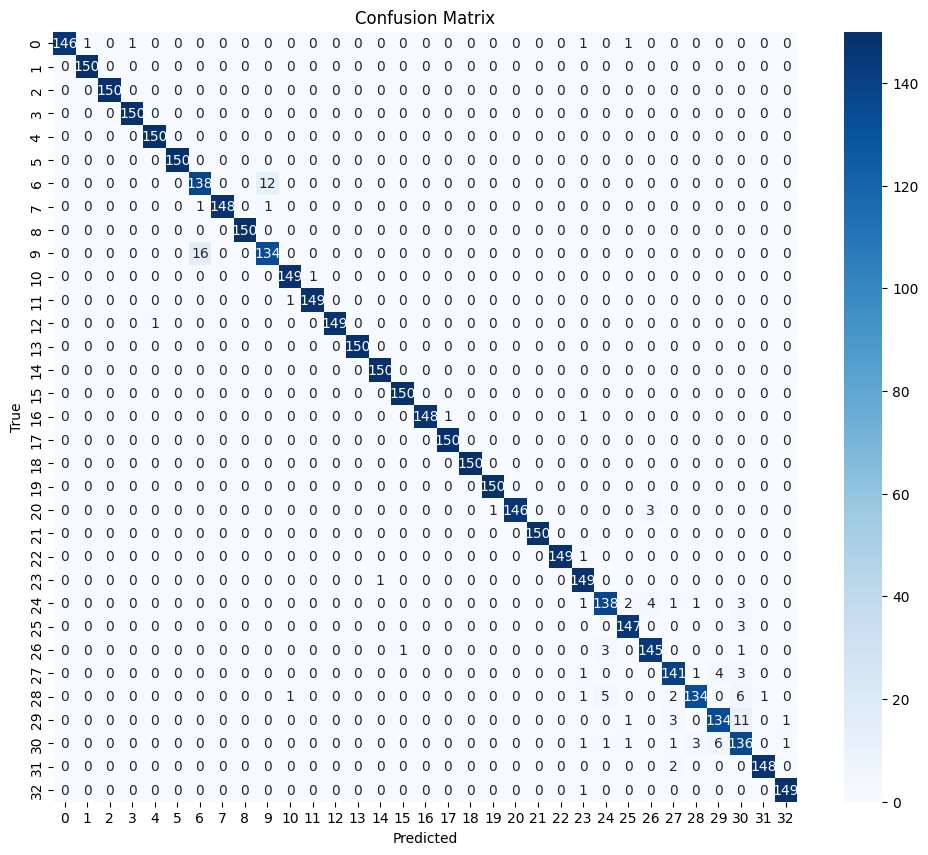

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [28]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = y_pred_probs.shape[1]

y_true_bin = label_binarize(y_true, classes=range(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

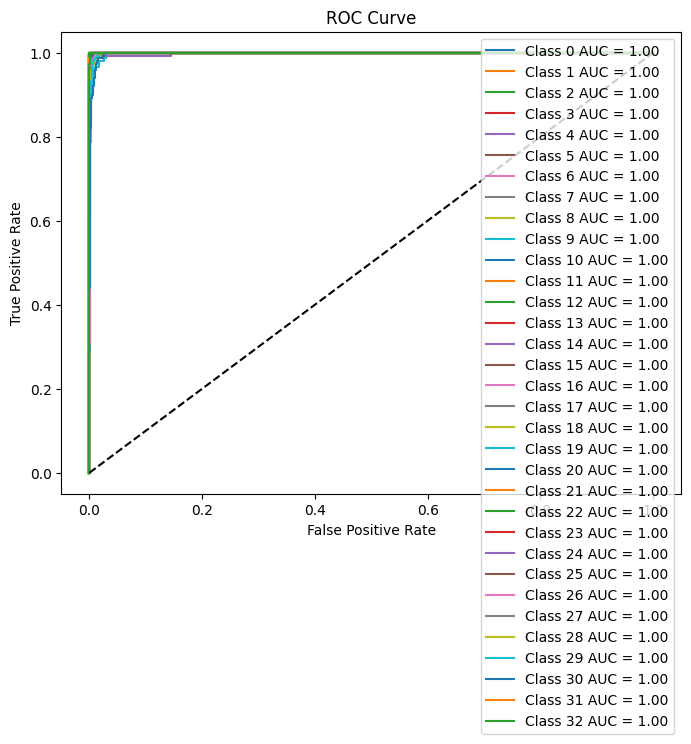

In [29]:
plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} AUC = {roc_auc[i]:.2f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [30]:
model.save("../data/models/plant_disease_model.keras")